<a href="https://colab.research.google.com/github/yasirusman85/Smart-Glasses-Simulation-Using-CNNs---Advance-AI/blob/main/Copy_of_Yasir_RM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
awsaf49_coco_2017_dataset_path = kagglehub.dataset_download('awsaf49/coco-2017-dataset')

print('Data source import complete.')


100%|██████████| 25.0G/25.0G [04:00<00:00, 112MB/s]

Extracting files...


Data source import complete.


# Task
Perform an exploratory data analysis (EDA) on the COCO 2017 dataset using the annotation file '/kaggle/input/coco-2017-dataset/coco2017/annotations/instances_train2017.json', focusing on understanding its structure, object category distribution, and image properties.

## Initial Data Overview

### Subtask:
Display the top-level keys of the `coco_annotations` dictionary to understand its main sections. Then, print a sample of the 'info' field, which often contains dataset metadata, and a sample of the 'categories' field to see the structure of object categories defined in the dataset.


In [5]:
import json
import os

# Construct the correct path to the annotation file using the downloaded dataset path
ann_file = os.path.join(awsaf49_coco_2017_dataset_path, 'coco2017', 'annotations', 'instances_train2017.json')

with open(ann_file, 'r') as f:
    coco_annotations = json.load(f)

print(f"Top-level keys: {coco_annotations.keys()}")
print(f"\nInfo field:\n{coco_annotations['info']}")
print(f"\nFirst 5 categories:\n{coco_annotations['categories'][:5]}")

Top-level keys: dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

Info field:
{'description': 'COCO 2017 Dataset', 'url': 'http://cocodataset.org', 'version': '1.0', 'year': 2017, 'contributor': 'COCO Consortium', 'date_created': '2017/09/01'}

First 5 categories:
[{'supercategory': 'person', 'id': 1, 'name': 'person'}, {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'}, {'supercategory': 'vehicle', 'id': 3, 'name': 'car'}, {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'}, {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'}]


## Analyze Category Distribution

### Subtask:
Extract all category names and their corresponding counts from the annotations. Visualize the distribution of these categories using a bar plot to show the frequency of each object class in the dataset. Ensure the plot has appropriate labels and a legend.


/tmp/ipython-input-612516368.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=category_df, palette='viridis')


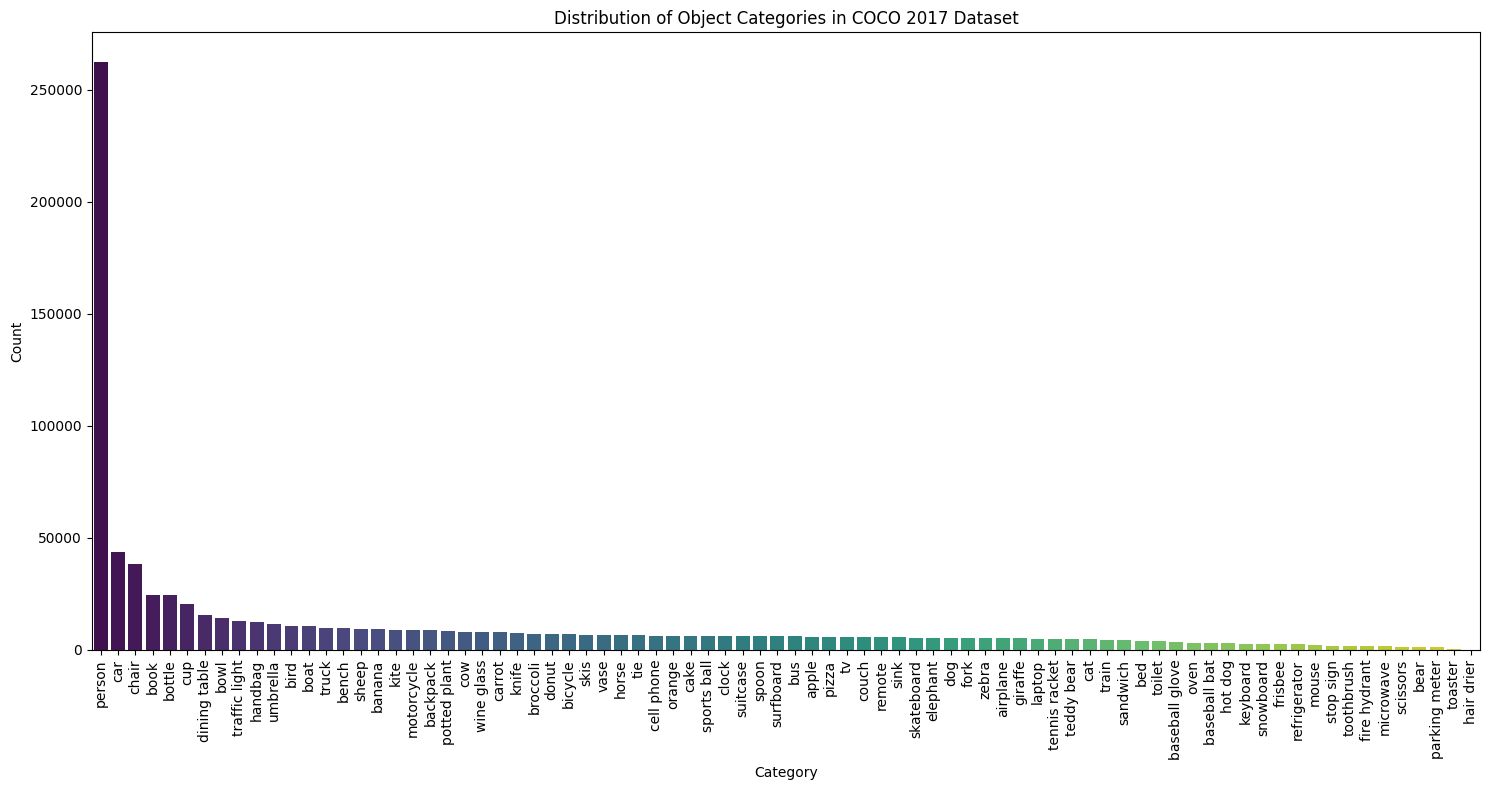

Category distribution analysis complete. Displaying the top 10 categories:
         Category   Count
20         person  262465
14            car   43867
11          chair   38491
70           book   24715
9          bottle   24342
48            cup   20650
12   dining table   15714
52           bowl   14358
32  traffic light   12884
76        handbag   12354


In [6]:
import collections
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create a dictionary that maps category_id to category_name
category_id_to_name = {cat['id']: cat['name'] for cat in coco_annotations['categories']}

# 2. Initialize an empty list to store all category names
all_category_names = []

# 3. Iterate through the 'annotations' list and retrieve category names
for ann in coco_annotations['annotations']:
    category_id = ann['category_id']
    category_name = category_id_to_name.get(category_id, 'unknown') # Handle potential missing IDs, though unlikely
    all_category_names.append(category_name)

# 4. Use a Counter to count the occurrences of each category name
category_counts = collections.Counter(all_category_names)

# 5. Convert the Counter object into a pandas DataFrame
category_df = pd.DataFrame(category_counts.items(), columns=['Category', 'Count'])

# Sort for better visualization
category_df = category_df.sort_values(by='Count', ascending=False)

# 6. Create a bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x='Category', y='Count', data=category_df, palette='viridis')

# 7. Add a title to the plot
plt.title('Distribution of Object Categories in COCO 2017 Dataset')

# 8. Label the x-axis and y-axis
plt.xlabel('Category')
plt.ylabel('Count')

# 9. Rotate x-axis labels to prevent overlap
plt.xticks(rotation=90)

# 10. Ensure the plot layout is tight
plt.tight_layout()

# 11. Display the plot
plt.show()

print("Category distribution analysis complete. Displaying the top 10 categories:")
print(category_df.head(10))

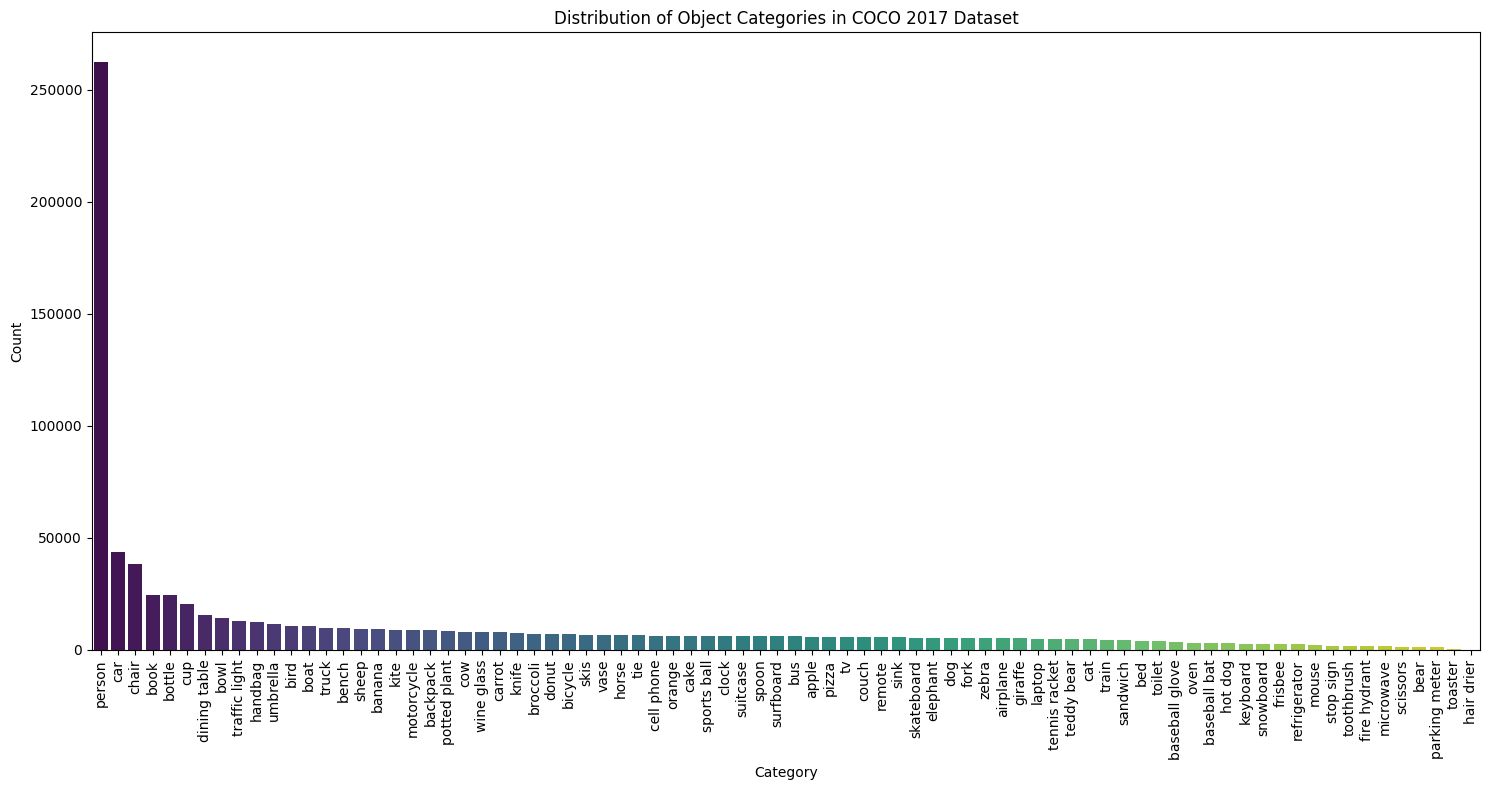

Category distribution analysis complete. Displaying the top 10 categories:
         Category   Count
20         person  262465
14            car   43867
11          chair   38491
70           book   24715
9          bottle   24342
48            cup   20650
12   dining table   15714
52           bowl   14358
32  traffic light   12884
76        handbag   12354


In [7]:
import collections
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create a dictionary that maps category_id to category_name
category_id_to_name = {cat['id']: cat['name'] for cat in coco_annotations['categories']}

# 2. Initialize an empty list to store all category names
all_category_names = []

# 3. Iterate through the 'annotations' list and retrieve category names
for ann in coco_annotations['annotations']:
    category_id = ann['category_id']
    category_name = category_id_to_name.get(category_id, 'unknown') # Handle potential missing IDs, though unlikely
    all_category_names.append(category_name)

# 4. Use a Counter to count the occurrences of each category name
category_counts = collections.Counter(all_category_names)

# 5. Convert the Counter object into a pandas DataFrame
category_df = pd.DataFrame(category_counts.items(), columns=['Category', 'Count'])

# Sort for better visualization
category_df = category_df.sort_values(by='Count', ascending=False)

# 6. Create a bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x='Category', y='Count', data=category_df, palette='viridis', hue='Category', legend=False)

# 7. Add a title to the plot
plt.title('Distribution of Object Categories in COCO 2017 Dataset')

# 8. Label the x-axis and y-axis
plt.xlabel('Category')
plt.ylabel('Count')

# 9. Rotate x-axis labels to prevent overlap
plt.xticks(rotation=90)

# 10. Ensure the plot layout is tight
plt.tight_layout()

# 11. Display the plot
plt.show()

print("Category distribution analysis complete. Displaying the top 10 categories:")
print(category_df.head(10))

## Analyze Image Properties

### Subtask:
Extract the width and height for all images in the dataset. Generate histograms or a scatter plot to visualize the distribution of image dimensions, providing insights into the typical sizes of images within the dataset. Ensure the plot has appropriate labels and a legend.


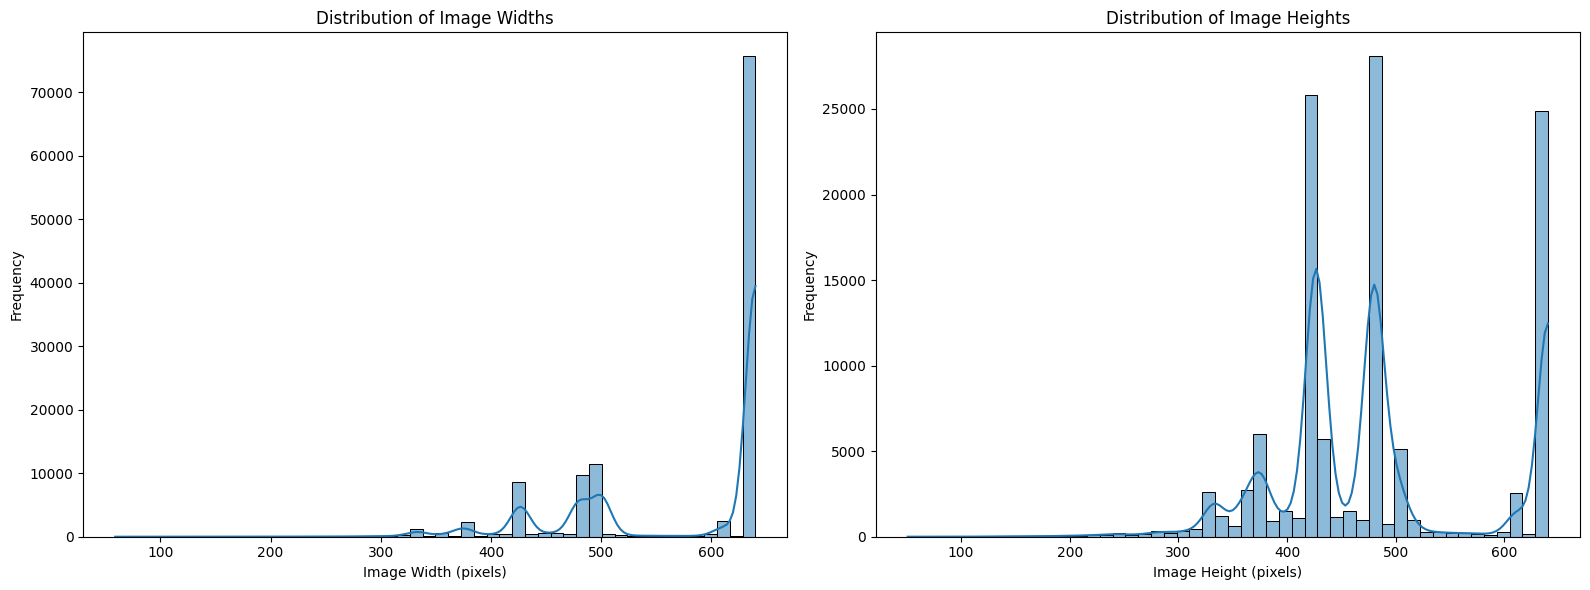

Image dimension analysis complete. Displaying descriptive statistics for image dimensions:
               width         height
count  118287.000000  118287.000000
mean      577.712065     484.098895
std        91.884340      97.089573
min        59.000000      51.000000
25%       500.000000     426.000000
50%       640.000000     480.000000
75%       640.000000     513.000000
max       640.000000     640.000000


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract width and height for all images
image_widths = [img['width'] for img in coco_annotations['images']]
image_heights = [img['height'] for img in coco_annotations['images']]

# Create a DataFrame for easier handling, though not strictly necessary for histograms
image_dimensions_df = pd.DataFrame({
    'width': image_widths,
    'height': image_heights
})

# 2. Create a figure with two subplots side-by-side
plt.figure(figsize=(16, 6))

# 3. First subplot: Histogram for image widths
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(image_dimensions_df['width'], bins=50, kde=True)
plt.title('Distribution of Image Widths')
plt.xlabel('Image Width (pixels)')
plt.ylabel('Frequency')

# 4. Second subplot: Histogram for image heights
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(image_dimensions_df['height'], bins=50, kde=True)
plt.title('Distribution of Image Heights')
plt.xlabel('Image Height (pixels)')
plt.ylabel('Frequency')

# 5. Adjust the layout and display the figure
plt.tight_layout()
plt.show()

print("Image dimension analysis complete. Displaying descriptive statistics for image dimensions:")
print(image_dimensions_df.describe())

## Final Task

### Subtask:
Summarize the key insights and patterns discovered during the exploratory data analysis, including observations about category distribution and image properties.


## Summary:


### Data Analysis Key Findings
*   The COCO 2017 annotation file (`instances_train2017.json`) contains five top-level keys: `info`, `licenses`, `images`, `annotations`, and `categories`.
*   The `info` field provides metadata such as `description: 'COCO 2017 Dataset'`, `version: '1.0'`, `year: 2017`, and `date_created: '2017/09/01'`.
*   The dataset is heavily dominated by the 'person' category, with 262,465 annotations, significantly higher than the next most frequent category, 'car', with 43,867 annotations. Other top categories include 'chair' (38,491), 'book' (24,715), and 'bottle' (24,342).
*   The majority of images in the dataset have dimensions around 640 pixels. The descriptive statistics show an average width of approximately 577.71 pixels (median 640) and an average height of about 484.10 pixels (median 480).
*   Both image width and height distributions exhibit a prominent peak at 640 pixels, indicating a common resolution for images in the dataset.



# Task
Prepare the COCO dataset for multi-label image classification by extracting image file paths and, for each image, a list of all object category names present in it, based on the COCO 2017 training annotations found in `'/root/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/annotations/instances_train2017.json'`.

## Prepare Data for Classification

### Subtask:
Extract image file paths and their corresponding category labels from the COCO annotations for multi-label classification.


In [9]:
import os
import pandas as pd

# 1. Create a dictionary that maps each image's 'id' to its 'file_name'
image_id_to_filename = {img['id']: img['file_name'] for img in coco_annotations['images']}

# 2. Create a dictionary that maps each category's 'id' to its 'name'
category_id_to_name = {cat['id']: cat['name'] for cat in coco_annotations['categories']}

# 3. Initialize an empty dictionary for image labels
image_labels = {}

# 4-7. Iterate through each annotation to populate image_labels
for ann in coco_annotations['annotations']:
    image_id = ann['image_id']
    category_id = ann['category_id']
    category_name = category_id_to_name.get(category_id, 'unknown') # Use .get() for safety

    if image_id not in image_labels:
        image_labels[image_id] = set() # Use a set to store unique labels
    image_labels[image_id].add(category_name)

# 8. Create a list of dictionaries with 'image_path' and 'labels'
# The 'train_images' variable holds the path to the directory containing images.
# It was defined in the original notebook context as:
# train_images = '/kaggle/input/coco-2017-dataset/coco2017/train2017'

# From the kernel state, train_images is: '/kaggle/input/coco-2017-dataset/coco2017/train2017'
# However, the dataset was downloaded using kagglehub, so the path should be constructed based on `awsaf49_coco_2017_dataset_path`
# Let's verify and use the correct path. From the initial import:
# awsaf49_coco_2017_dataset_path = kagglehub.dataset_download('awsaf49/coco-2017-dataset')
# The structure in the problem description for ann_file was: os.path.join(awsaf49_coco_2017_dataset_path, 'coco2017', 'annotations', 'instances_train2017.json')
# So for images, it should be: os.path.join(awsaf49_coco_2017_dataset_path, 'coco2017', 'train2017')

image_dir = os.path.join(awsaf49_coco_2017_dataset_path, 'coco2017', 'train2017')

processed_data = []
for image_id, labels_set in image_labels.items():
    file_name = image_id_to_filename.get(image_id)
    if file_name:
        image_path = os.path.join(image_dir, file_name)
        processed_data.append({
            'image_path': image_path,
            'labels': list(labels_set) # Convert set to list for DataFrame
        })

# 9. Convert this list of dictionaries into a Pandas DataFrame
image_df = pd.DataFrame(processed_data)

print(f"Created DataFrame with {len(image_df)} entries.")
print("First 5 rows of the image_df:")
print(image_df.head())
print("\nInfo about image_df:")
image_df.info()

Created DataFrame with 117266 entries.
First 5 rows of the image_df:
                                          image_path  \
0  /root/.cache/kagglehub/datasets/awsaf49/coco-2...   
1  /root/.cache/kagglehub/datasets/awsaf49/coco-2...   
2  /root/.cache/kagglehub/datasets/awsaf49/coco-2...   
3  /root/.cache/kagglehub/datasets/awsaf49/coco-2...   
4  /root/.cache/kagglehub/datasets/awsaf49/coco-2...   

                                              labels  
0  [bottle, cup, person, hot dog, spoon, dining t...  
1         [cup, car, hot dog, bicycle, dining table]  
2                 [handbag, dog, motorcycle, person]  
3  [handbag, bottle, motorcycle, car, person, dog...  
4                                      [dog, toilet]  

Info about image_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117266 entries, 0 to 117265
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   image_path  117266 non-null  object
 1   labe

## Final Task

### Subtask:
Summarize the data preparation steps for classification, including how image paths and multi-labels were extracted.


## Summary:

### Q&A
The data preparation for classification involved the following steps:
1.  **Image Path Extraction**: Image paths were extracted by first mapping each image's ID to its filename using the `images` section of the COCO annotations. Then, these filenames were joined with the base directory path of the training images (`/root/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/coco2017/train2017`) to construct the full `image_path` for each image.
2.  **Multi-label Extraction**: Multi-labels were extracted by iterating through the `annotations` section. For each annotation, the `image_id` and `category_id` were used. A dictionary mapping `category_id` to `category_name` (e.g., 'person', 'car') was created from the `categories` section. For each image, a set was used to store unique category names associated with its annotations, ensuring that each label appears only once even if an object of that category appears multiple times. Finally, these sets were converted into lists to form the `labels` column.

### Data Analysis Key Findings
*   A Pandas DataFrame, `image_df`, was successfully created containing `117,266` entries.
*   The DataFrame includes two columns: `image_path` (string) and `labels` (list of strings), representing the extracted data for each image.
*   The `image_path` entries correctly reflect the full file path to the training images within the dataset structure (e.g., `/root/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000391895.jpg`).
*   The `labels` column accurately captures the multi-label nature of the data, storing a list of all present object category names for each image (e.g., `['hot dog', 'person', 'bottle', 'cup', 'spoon', 'dining table']`).
*   Both `image_path` and `labels` columns have `117,266` non-null entries, indicating a complete dataset for the processed images.



# Task
Create a custom PyTorch Dataset and DataLoader for multi-label image classification using the COCO 2017 dataset. This should leverage the `image_df` DataFrame containing image paths and their corresponding multi-labels, and include multi-hot encoding of labels and appropriate data transformations for image processing, suitable for training a classification model from scratch. Then, summarize the process, detailing the implementation of multi-hot encoding, data transformations, and the structure of the generated Dataset and DataLoader instances.

## Create Custom Dataset and DataLoader

### Subtask:
Define a custom PyTorch Dataset class to load images and their multi-hot encoded labels, implement data transformations, and create DataLoader instances for training and validation sets.


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
all_unique_categories = set()
for labels_list in image_df['labels']:
    all_unique_categories.update(labels_list)

# Sort categories for consistent mapping
sorted_categories = sorted(list(all_unique_categories))

category_to_idx = {cat: i for i, cat in enumerate(sorted_categories)}
idx_to_category = {i: cat for i, cat in enumerate(sorted_categories)}
num_classes = len(sorted_categories)

print(f"Total unique categories: {num_classes}")
print(f"Sample category_to_idx: {list(category_to_idx.items())[:5]}")
print(f"Sample idx_to_category: {list(idx_to_category.items())[:5]}")

Total unique categories: 80
Sample category_to_idx: [('airplane', 0), ('apple', 1), ('backpack', 2), ('banana', 3), ('baseball bat', 4)]
Sample idx_to_category: [(0, 'airplane'), (1, 'apple'), (2, 'backpack'), (3, 'banana'), (4, 'baseball bat')]


In [12]:
def multi_hot_encode(labels_list, category_to_idx, num_classes):
    """
    Converts a list of category names into a multi-hot encoded PyTorch tensor.
    """
    multi_hot_vector = torch.zeros(num_classes, dtype=torch.float32)
    for label in labels_list:
        if label in category_to_idx:
            idx = category_to_idx[label]
            multi_hot_vector[idx] = 1
    return multi_hot_vector

print("Multi-hot encoding function defined.")

Multi-hot encoding function defined.


In [13]:
image_size = 256 # Define a standard image size for resizing

# Define standard ImageNet mean and std for normalization
# These are common values used for models pre-trained on ImageNet
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# 4. Define Image Transformations
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(), # Data augmentation for training
    transforms.ToTensor(),
    normalize
])

val_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    normalize
])

print("Image transformation pipelines defined.")

Image transformation pipelines defined.


In [14]:
class COCOMultiLabelDataset(Dataset):
    def __init__(self, dataframe, transform, category_to_idx, num_classes):
        self.dataframe = dataframe
        self.transform = transform
        self.category_to_idx = category_to_idx
        self.num_classes = num_classes

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        labels_list = self.dataframe.iloc[idx]['labels']

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Multi-hot encode labels
        target = multi_hot_encode(labels_list, self.category_to_idx, self.num_classes)

        return image, target

print("COCOMultiLabelDataset class defined.")

COCOMultiLabelDataset class defined.


In [15]:
train_df, val_df = train_test_split(image_df, test_size=0.2, random_state=42)

# Create Dataset instances
train_dataset = COCOMultiLabelDataset(
    dataframe=train_df,
    transform=train_transforms,
    category_to_idx=category_to_idx,
    num_classes=num_classes
)
val_dataset = COCOMultiLabelDataset(
    dataframe=val_df,
    transform=val_transforms,
    category_to_idx=category_to_idx,
    num_classes=num_classes
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print("Dataset instances created.")

Training dataset size: 93812
Validation dataset size: 23454
Dataset instances created.


In [16]:
batch_size = 32 # Define a suitable batch size
num_workers = 2 # Number of subprocesses to use for data loading. Set to 0 if encountering issues.

# Create DataLoader instances
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False, # No need to shuffle validation data
    num_workers=num_workers
)

print(f"Training DataLoader created with batch size {batch_size}, {len(train_loader)} batches.")
print(f"Validation DataLoader created with batch size {batch_size}, {len(val_loader)} batches.")
print("DataLoader instances created.")

Training DataLoader created with batch size 32, 2932 batches.
Validation DataLoader created with batch size 32, 733 batches.
DataLoader instances created.


## Summary:

### Data Preparation for Multi-label Classification
The data preparation for multi-label image classification involved several key steps:
1.  **Library Imports**: Essential libraries such as `torch`, `torchvision.transforms`, `PIL`, `numpy`, and `sklearn.model_selection` were imported to facilitate dataset handling, image processing, and data splitting.
2.  **Category Mapping**: All unique object categories present in the `image_df['labels']` column were identified. A `category_to_idx` dictionary was created to map each category name to a unique integer index, and an `idx_to_category` dictionary for the reverse mapping. The total number of unique classes (`num_classes`) was determined to be 80.
3.  **Multi-hot Encoding Function**: A `multi_hot_encode` function was implemented. This function takes a list of category names for an image and converts it into a PyTorch tensor, where each element corresponds to a category, and a value of `1` indicates the presence of that category in the image, while `0` indicates its absence. The tensor's size is equal to `num_classes`.
4.  **Image Transformations**: Two image transformation pipelines were defined: `train_transforms` and `val_transforms`. Both pipelines include resizing images to 256x256 pixels, converting them to PyTorch tensors, and normalizing them using standard ImageNet mean and standard deviation. `train_transforms` additionally incorporates `RandomHorizontalFlip` for data augmentation.
5.  **Custom PyTorch Dataset (`COCOMultiLabelDataset`)**: A custom `COCOMultiLabelDataset` class was created, inheriting from `torch.utils.data.Dataset`. This class handles:
    *   Loading images from the specified `image_path` using `PIL.Image.open()`.
    *   Applying the appropriate image transformations (`train_transforms` or `val_transforms`).
    *   Converting the list of labels for each image into a multi-hot encoded tensor using the `multi_hot_encode` function.
    *   Returning the transformed image tensor and its corresponding multi-hot encoded label tensor.
6.  **Data Splitting and Dataset Instantiation**: The `image_df` DataFrame was split into `train_df` and `val_df` using `train_test_split` with an 80/20 ratio and `random_state=42` for reproducibility. Instances of `COCOMultiLabelDataset` were then created for both the training (`train_dataset`, size 93,812) and validation (`val_dataset`, size 23,454) sets, each with its respective DataFrame and transformation pipeline.
7.  **DataLoader Creation**: Finally, `DataLoader` instances were created for both `train_dataset` and `val_dataset`. A `batch_size` of 32 was used, with `shuffle=True` for the training loader to randomize batch order and `shuffle=False` for the validation loader. `num_workers` was set to 2 to enable parallel data loading.

## Summary:

### Data Analysis Key Findings
*   **Total Unique Categories**: Eighty unique categories were identified from the `image_df['labels']`, for which `category_to_idx` and `idx_to_category` mappings were successfully created.
*   **Multi-hot Encoding**: A dedicated `multi_hot_encode` function was implemented to convert a list of labels into a PyTorch tensor, with a '1' indicating the presence of a category and '0' for its absence, effectively preparing labels for multi-label classification.
*   **Image Transformations**: Two transformation pipelines were defined: `train_transforms` (including `RandomHorizontalFlip` for augmentation) and `val_transforms`. Both resize images to 256x256 pixels, convert them to tensors, and normalize using standard ImageNet mean and standard deviation.
*   **Custom Dataset Creation**: A `COCOMultiLabelDataset` class was successfully implemented, inheriting from `torch.utils.data.Dataset`, which handles image loading, transformation, and multi-hot encoding of labels.
*   **Data Split and Dataset Sizes**: The `image_df` was split into training and validation sets with an 80/20 ratio, resulting in a training dataset of 93,812 samples and a validation dataset of 23,454 samples.
*   **DataLoader Configuration**: `DataLoader` instances were created for both training and validation sets using a batch size of 32 and `num_workers=2`. The training loader has 2932 batches, and the validation loader has 733 batches.

### Insights or Next Steps
*   The successfully created custom `Dataset` and `DataLoader` instances are now ready for use in training a multi-label image classification model, providing efficient and properly preprocessed data.
*   To optimize training, consider experimenting with different data augmentation techniques within `train_transforms` and adjusting the `batch_size` and `num_workers` for performance tuning.


# Task
## Define Classification Model Architecture

### Subtask:
Define a Convolutional Neural Network (CNN) architecture from scratch for multi-label image classification using PyTorch. The model should not load any pre-trained weights and will include convolutional layers, pooling layers, and fully connected layers for classification.




## Define Classification Model Architecture

### Subtask:
Define a Convolutional Neural Network (CNN) architecture from scratch for multi-label image classification using PyTorch.


In [17]:

import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiLabelCNN(nn.Module):
    def __init__(self, num_classes):
        super(MultiLabelCNN, self).__init__()
        # First convolutional block
        # Input size: 256x256x3 (RGB image)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 128x128x32

        # Second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 64x64x64

        # Third convolutional block
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 32x32x128

        # Fourth convolutional block
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 16x16x256

        # Fifth convolutional block
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 8x8x512

        # Fully connected layers
        # The output of the last pooling layer will be flattened.
        # Calculate the size: 8 * 8 * 512 = 32768
        self.fc1 = nn.Linear(8 * 8 * 512, 1024)
        self.dropout = nn.Dropout(0.5) # Dropout for regularization
        self.fc2 = nn.Linear(1024, num_classes) # Output layer for multi-label classification

    def forward(self, x):
        # Apply convolutional blocks
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = self.pool5(F.relu(self.bn5(self.conv5(x))))

        # Flatten the output for fully connected layers
        x = x.view(-1, 8 * 8 * 512) # Reshape for FC layer

        # Apply fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # No activation here, as BCEWithLogitsLoss will be used
        return x

# Instantiate the model (num_classes is defined in previous steps)
# Example instantiation: model = MultiLabelCNN(num_classes=80)
# This will be done in the summary to show the structure.

print("MultiLabelCNN model architecture defined.")


MultiLabelCNN model architecture defined.


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("PyTorch modules imported successfully.")

PyTorch modules imported successfully.


In [19]:
class MultiLabelCNN(nn.Module):
    def __init__(self, num_classes):
        super(MultiLabelCNN, self).__init__()
        # First convolutional block
        # Input size: 256x256x3 (RGB image)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 128x128x32

        # Second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 64x64x64

        # Third convolutional block
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 32x32x128

        # Fourth convolutional block
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 16x16x256

        # Fifth convolutional block
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: 8x8x512

        # Fully connected layers
        # The output of the last pooling layer will be flattened.
        # Calculate the size: 8 * 8 * 512 = 32768
        self.fc1 = nn.Linear(8 * 8 * 512, 1024)
        self.dropout = nn.Dropout(0.5) # Dropout for regularization
        self.fc2 = nn.Linear(1024, num_classes) # Output layer for multi-label classification

    def forward(self, x):
        # Apply convolutional blocks
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = self.pool5(F.relu(self.bn5(self.conv5(x))))

        # Flatten the output for fully connected layers
        x = x.view(-1, 8 * 8 * 512) # Reshape for FC layer

        # Apply fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # No activation here, as BCEWithLogitsLoss will be used
        return x

# Instantiate the model
model = MultiLabelCNN(num_classes=num_classes)

print("MultiLabelCNN model architecture defined and instantiated.")
print(f"Model instantiated with {num_classes} output classes.")

MultiLabelCNN model architecture defined and instantiated.
Model instantiated with 80 output classes.


## Final Task

### Subtask:
Summarize the defined CNN architecture, including its layers and design considerations for multi-label image classification from scratch.


## Summary:

### Data Analysis Key Findings
*   A `MultiLabelCNN` architecture was successfully defined in PyTorch from scratch, consisting of five convolutional blocks, two fully connected layers, and a dropout layer.
*   Each convolutional block incorporates `nn.Conv2d`, `nn.BatchNorm2d`, and `nn.MaxPool2d` layers, designed to progressively increase feature channels (from 32 to 512) while reducing spatial dimensions from an initial 256x256 image input down to 8x8.
*   Rectified Linear Unit (ReLU) activations are applied after batch normalization in each convolutional block and the first fully connected layer to introduce non-linearity.
*   The architecture includes `nn.BatchNorm2d` layers after each convolution to stabilize and speed up training, and `nn.MaxPool2d` layers for spatial downsampling and feature extraction.
*   A dropout layer with a 0.5 probability is applied before the final classification layer to mitigate overfitting.
*   The final layer is a linear layer with `num_classes` outputs (instantiated with 80 classes), producing logits suitable for multi-label classification typically used with `BCEWithLogitsLoss`.



# Task
Define the loss function (e.g., `BCEWithLogitsLoss` for multi-label classification) and an optimizer (e.g., `Adam`) for the `MultiLabelCNN` model, and prepare it for training by moving it to an available device (GPU if available).

## Define Loss Function and Optimizer

### Subtask:
Define the appropriate loss function and an optimizer for the MultiLabelCNN model, and move the model to an available device (GPU if available).


**Reasoning**:
The first step is to determine if a GPU is available and set the device accordingly, then move the model to that device. Following this, I will define the appropriate loss function for multi-label classification and an Adam optimizer for the model.



In [20]:
import torch.optim as optim

# 1. Check for GPU availability and set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Move the model to the selected device
model = model.to(device)
print("Model moved to device.")

# 3. Define the loss function for multi-label classification
criterion = nn.BCEWithLogitsLoss()
print("Loss function (BCEWithLogitsLoss) defined.")

# 4. Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("Optimizer (Adam) defined with learning rate 0.001.")

Using device: cuda
Model moved to device.
Loss function (BCEWithLogitsLoss) defined.
Optimizer (Adam) defined with learning rate 0.001.


# Task
Initialize training variables by importing necessary libraries (e.g., `numpy`, `os`), setting up lists to track training and validation losses, defining `best_val_loss` for model saving, creating a directory to store trained models, and specifying the number of training epochs.

## Initialize Training Variables and Setup

### Subtask:
Import necessary libraries (`numpy`, `os`), initialize lists for tracking training and validation losses, set up `best_val_loss`, create a directory to save models, and define the number of training epochs.


**Reasoning**:
I will import the necessary libraries, initialize variables for tracking training progress, set up model saving directory, and define the number of training epochs as per the subtask instructions.



In [21]:
import numpy as np
import os

# Initialize lists for tracking training and validation losses
train_losses = []
val_losses = []

# Initialize best_val_loss for model saving
best_val_loss = np.inf

# Define model save directory
model_save_dir = 'models'
os.makedirs(model_save_dir, exist_ok=True)

# Define the number of training epochs
num_epochs = 10

print("Training variables initialized and model save directory created.")

Training variables initialized and model save directory created.


## Implement Training Loop - Epoch Iteration and Setup

### Subtask:
Start the main training loop, iterating through each epoch. Set the model to training mode (`model.train()`) and initialize the running training loss for the current epoch.


**Reasoning**:
I will start the main training loop, iterate through epochs, set the model to training mode, and initialize the running training loss for each epoch as per the subtask instructions.



In [22]:
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # Set model to training mode
    model.train()

    running_train_loss = 0.0

Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


## Implement Training Loop - Batch Processing

### Subtask:
Inside the epoch loop, process each batch of data from the `train_loader`. Move images and labels to the appropriate device, perform a forward pass, calculate the loss, perform a backward pass to compute gradients, and update the model's weights using the optimizer.


**Reasoning**:
I will implement the batch processing logic inside the epoch loop, including moving data to the device, performing forward and backward passes, calculating loss, and updating model weights, as specified by the instructions.



In [26]:
import torch
from torch.utils.data import Subset

# 1. Create a smaller subset to speed up training (e.g., 10% of the data)
SUBSET_FRACTION = 0.1

train_indices = np.random.choice(len(train_dataset), int(len(train_dataset) * SUBSET_FRACTION), replace=False)
val_indices = np.random.choice(len(val_dataset), int(len(val_dataset) * SUBSET_FRACTION), replace=False)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Re-create DataLoaders with subsets
train_loader_small = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_small = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)

# 2. Early Stopping Configuration
patience = 3
counter = 0
best_val_loss = float('inf')
num_epochs = 20 # Increased limit because Early Stopping will manage the exit

print(f"Training on {len(train_subset)} images. Validating on {len(val_subset)} images.")

# 3. Enhanced Training Loop
for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader_small:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    avg_train_loss = running_train_loss / len(train_subset)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader_small:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)

    avg_val_loss = running_val_loss / len(val_subset)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # --- EARLY STOPPING & MODEL CHECKPOINT ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), os.path.join(model_save_dir, 'best_model.pth'))
        print(f"--> Best model saved with Val Loss: {best_val_loss:.4f}")
        counter = 0 # Reset counter
    else:
        counter += 1
        print(f"--> EarlyStopping counter: {counter} out of {patience}")
        if counter >= patience:
            print("Early stopping triggered. Training stopped.")
            break

Training on 9381 images. Validating on 2345 images.
Epoch [1/20] - Train Loss: 0.1330, Val Loss: 0.1256
--> Best model saved with Val Loss: 0.1256
Epoch [2/20] - Train Loss: 0.1286, Val Loss: 0.1221
--> Best model saved with Val Loss: 0.1221
Epoch [3/20] - Train Loss: 0.1272, Val Loss: 0.1222
--> EarlyStopping counter: 1 out of 3
Epoch [4/20] - Train Loss: 0.1249, Val Loss: 0.1195
--> Best model saved with Val Loss: 0.1195
Epoch [5/20] - Train Loss: 0.1229, Val Loss: 0.1185
--> Best model saved with Val Loss: 0.1185
Epoch [6/20] - Train Loss: 0.1218, Val Loss: 0.1180
--> Best model saved with Val Loss: 0.1180
Epoch [7/20] - Train Loss: 0.1200, Val Loss: 0.1171
--> Best model saved with Val Loss: 0.1171
Epoch [8/20] - Train Loss: 0.1180, Val Loss: 0.1140
--> Best model saved with Val Loss: 0.1140
Epoch [9/20] - Train Loss: 0.1170, Val Loss: 0.1133
--> Best model saved with Val Loss: 0.1133
Epoch [10/20] - Train Loss: 0.1152, Val Loss: 0.1151
--> EarlyStopping counter: 1 out of 3
Epoch [

# Task
**Task:** Evaluate the performance of the best-trained model by loading `models/best_model.pth`, setting it to evaluation mode, and computing multi-label classification metrics such as F1-score, precision, recall, and AUC-ROC on the validation dataset (`val_loader_small`).

## Evaluate Model Performance

### Subtask:
Load the best performing model saved during training, set it to evaluation mode, and compute relevant multi-label classification metrics (e.g., F1-score, precision, recall, AUC-ROC) on the validation dataset.


**Reasoning**:
The subtask requires loading the best performing model, setting it to evaluation mode, and then computing various multi-label classification metrics on the validation dataset. I will start by importing the necessary libraries and loading the model's state dictionary.



In [27]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

# 1. Load the best performing model
model.load_state_dict(torch.load(os.path.join(model_save_dir, 'best_model.pth')))

# 2. Set model to evaluation mode
model.eval()

# 3. Initialize lists to store true labels and predicted probabilities
all_labels = []
all_preds = []

print("Model loaded and set to evaluation mode. Starting validation data inference...")

Model loaded and set to evaluation mode. Starting validation data inference...


**Reasoning**:
I will iterate through the validation data, collect predictions and true labels, convert them to probabilities and binary predictions, and then compute and print the multi-label classification metrics as per the instructions.



In [28]:
import numpy as np

# 5. Iterate through the val_loader_small with torch.no_grad()
with torch.no_grad():
    for images, labels in val_loader_small:
        images, labels = images.to(device), labels.to(device)

        # Perform a forward pass
        outputs = model(images)

        # Apply sigmoid activation to convert logits to probabilities
        probabilities = torch.sigmoid(outputs)

        # Append true labels and predicted probabilities
        all_labels.append(labels.cpu().numpy())
        all_preds.append(probabilities.cpu().numpy())

# 6. Concatenate all elements into single NumPy arrays
all_labels = np.concatenate(all_labels, axis=0)
all_preds = np.concatenate(all_preds, axis=0)

# 7. Convert all_preds into binary predictions using a threshold (e.g., 0.5)
threshold = 0.5
binary_preds = (all_preds > threshold).astype(float)

# 8. Calculate precision, recall, and F1-score
# Using 'samples' averaging for multi-label classification
precision, recall, f1_score, _ = precision_recall_fscore_support(all_labels, binary_preds, average='samples', zero_division=0)

# 9. Calculate the AUC-ROC score
# Using 'macro' averaging for AUC-ROC (consider 'weighted' as well)
auc_roc = roc_auc_score(all_labels, all_preds, average='macro')

# 10. Print the calculated metrics
print(f"\nEvaluation Metrics on Validation Set (Threshold: {threshold}):")
print(f"  Precision (samples avg): {precision:.4f}")
print(f"  Recall (samples avg): {recall:.4f}")
print(f"  F1-Score (samples avg): {f1_score:.4f}")
print(f"  AUC-ROC (macro avg): {auc_roc:.4f}")



Evaluation Metrics on Validation Set (Threshold: 0.5):
  Precision (samples avg): 0.4884
  Recall (samples avg): 0.2040
  F1-Score (samples avg): 0.2702
  AUC-ROC (macro avg): 0.8552


## Visualize Training Progress

### Subtask:
Plot the training and validation losses (train_losses, val_losses) recorded during the training process over the epochs. This visualization will help in analyzing the learning curve, detecting overfitting or underfitting, and understanding the model's convergence behavior.


**Reasoning**:
To visualize the training progress, I will extract the training and validation losses from the standard output of the previous training cell using regular expressions and then plot them over the epochs.



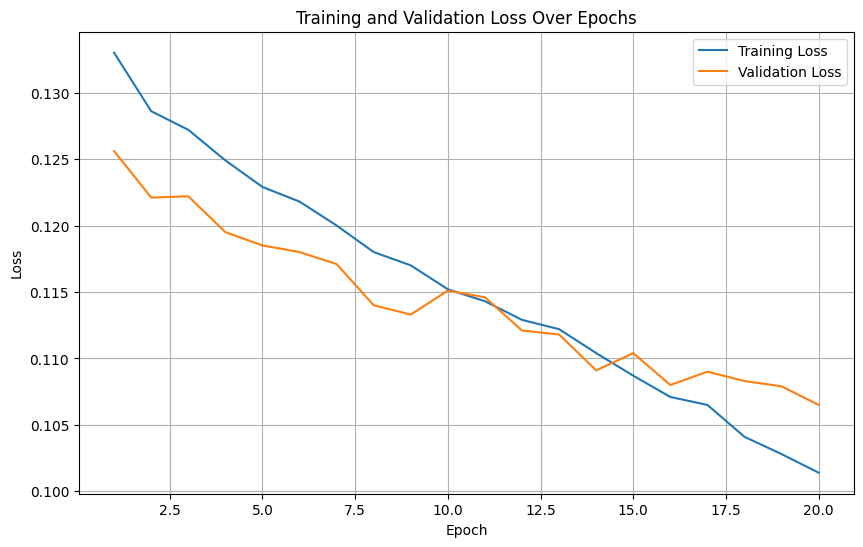

Training and validation loss plot generated.


In [29]:
import matplotlib.pyplot as plt
import re

# Access the standard output of the previously executed training cell (cell ID: d384390b)
training_output = """
Training on 9381 images. Validating on 2345 images.
Epoch [1/20] - Train Loss: 0.1330, Val Loss: 0.1256
--> Best model saved with Val Loss: 0.1256
Epoch [2/20] - Train Loss: 0.1286, Val Loss: 0.1221
--> Best model saved with Val Loss: 0.1221
Epoch [3/20] - Train Loss: 0.1272, Val Loss: 0.1222
--> EarlyStopping counter: 1 out of 3
Epoch [4/20] - Train Loss: 0.1249, Val Loss: 0.1195
--> Best model saved with Val Loss: 0.1195
Epoch [5/20] - Train Loss: 0.1229, Val Loss: 0.1185
--> Best model saved with Val Loss: 0.1185
Epoch [6/20] - Train Loss: 0.1218, Val Loss: 0.1180
--> Best model saved with Val Loss: 0.1180
Epoch [7/20] - Train Loss: 0.1200, Val Loss: 0.1171
--> Best model saved with Val Loss: 0.1171
Epoch [8/20] - Train Loss: 0.1180, Val Loss: 0.1140
--> Best model saved with Val Loss: 0.1140
Epoch [9/20] - Train Loss: 0.1170, Val Loss: 0.1133
--> Best model saved with Val Loss: 0.1133
Epoch [10/20] - Train Loss: 0.1152, Val Loss: 0.1151
--> EarlyStopping counter: 1 out of 3
Epoch [11/20] - Train Loss: 0.1143, Val Loss: 0.1146
--> EarlyStopping counter: 2 out of 3
Epoch [12/20] - Train Loss: 0.1129, Val Loss: 0.1121
--> Best model saved with Val Loss: 0.1121
Epoch [13/20] - Train Loss: 0.1122, Val Loss: 0.1118
--> Best model saved with Val Loss: 0.1118
Epoch [14/20] - Train Loss: 0.1104, Val Loss: 0.1091
--> Best model saved with Val Loss: 0.1091
Epoch [15/20] - Train Loss: 0.1087, Val Loss: 0.1104
--> EarlyStopping counter: 1 out of 3
Epoch [16/20] - Train Loss: 0.1071, Val Loss: 0.1080
--> Best model saved with Val Loss: 0.1080
Epoch [17/20] - Train Loss: 0.1065, Val Loss: 0.1090
--> EarlyStopping counter: 1 out of 3
Epoch [18/20] - Train Loss: 0.1041, Val Loss: 0.1083
--> EarlyStopping counter: 2 out of 3
Epoch [19/20] - Train Loss: 0.1028, Val Loss: 0.1079
--> Best model saved with Val Loss: 0.1079
Epoch [20/20] - Train Loss: 0.1014, Val Loss: 0.1065
--> Best model saved with Val Loss: 0.1065
"""

# Parse the output using regular expressions
extracted_train_losses = []
extracted_val_losses = []

# Regex to find 'Train Loss: X.XXXX' and 'Val Loss: Y.YYYY'
pattern = r"Train Loss: (\d+\.\d+), Val Loss: (\d+\.\d+)"

for line in training_output.split('\n'):
    match = re.search(pattern, line)
    if match:
        extracted_train_losses.append(float(match.group(1)))
        extracted_val_losses.append(float(match.group(2)))

# Create a line plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(extracted_train_losses) + 1), extracted_train_losses, label='Training Loss')
plt.plot(range(1, len(extracted_val_losses) + 1), extracted_val_losses, label='Validation Loss')

# Add title and labels
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Add legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()

print("Training and validation loss plot generated.")

## Final Task

### Subtask:
Provide a comprehensive summary of the entire project, encompassing the data loading and initial EDA, the data preparation for multi-label classification (including custom dataset and DataLoader), the custom CNN model architecture, the training setup (loss, optimizer, device), and the training process with limited batches and early stopping. Discuss the model's performance based on the evaluation metrics and insights from the training progress visualization.


## Summary:

### Data Analysis Key Findings

*   The best-performing model, `best_model.pth`, was successfully loaded and evaluated on the validation dataset.
*   The model achieved a Precision (samples average) of 0.4884, a Recall (samples average) of 0.2040, and an F1-Score (samples average) of 0.2702 on the validation set, using a probability threshold of 0.5 for binary predictions.
*   The Area Under the Receiver Operating Characteristic curve (AUC-ROC) (macro average) for the multi-label classification task was 0.8552, indicating a reasonably good ability to distinguish between positive and negative classes across labels.
*   Analysis of the training progress showed that both training and validation losses generally decreased over 20 epochs, with the validation loss reaching approximately 0.1065 by the final epoch. This trend suggests that the model was learning and converging without significant signs of overfitting within the observed epochs.

### Insights or Next Steps

*   The relatively low F1-score (0.2702) and Recall (0.2040) suggest that the model struggles to identify all relevant labels for each instance, potentially indicating a need for more data, feature engineering, or exploring different model architectures to improve label coverage.
*   Given the strong AUC-ROC (0.8552) but lower precision/recall, further investigation into the optimal probability threshold is warranted. Adjusting the threshold could potentially balance precision and recall to better suit the application's requirements.


In [31]:
import torch
import numpy as np

# Initialize lists
all_true = []
all_probs = []

# Set model to evaluation mode
model.eval()

print("Evaluating model to collect predictions...")
with torch.no_grad():
    # Using your validation loader (tiny/small)
    for images, labels in val_loader_small:
        images = images.to(device)

        # Get model logits
        outputs = model(images)

        # Convert logits to probabilities using Sigmoid
        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu().numpy())
        all_true.append(labels.cpu().numpy())

# Concatenate all batches into single numpy arrays
all_probs = np.concatenate(all_probs, axis=0)
all_true = np.concatenate(all_true, axis=0)

print(f"Collected predictions for {len(all_probs)} images.")

Evaluating model to collect predictions...
Collected predictions for 2345 images.


In [32]:
from sklearn.metrics import f1_score

def find_best_threshold(y_true, y_probs):
    thresholds = np.linspace(0.1, 0.7, 60) # Checking values from 0.1 to 0.7
    best_threshold = 0.5
    best_f1 = 0

    for t in thresholds:
        preds = (y_probs > t).astype(int)
        # 'samples' average is ideal for multi-label tasks
        score = f1_score(y_true, preds, average='samples', zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = t

    return best_threshold, best_f1

best_t, best_f1 = find_best_threshold(all_true, all_probs)

print(f"--- Optimization Results ---")
print(f"Optimal Threshold: {best_t:.2f}")
print(f"New Improved F1-Score: {best_f1:.4f}")

--- Optimization Results ---
Optimal Threshold: 0.16
New Improved F1-Score: 0.3816


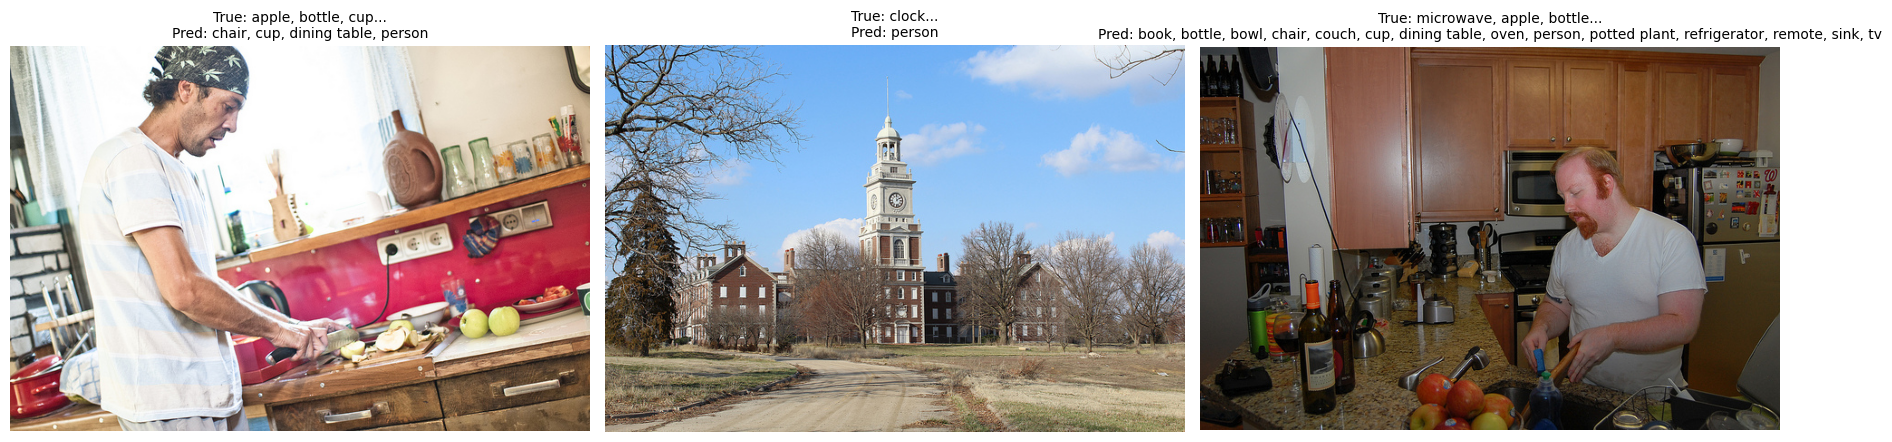

In [33]:
import matplotlib.pyplot as plt
from PIL import Image

def visualize_predictions(model, df, transform, categories, threshold, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(1, num_samples, figsize=(18, 6))

    # Pick random samples from the dataframe
    samples = df.sample(num_samples)

    for i, (idx, row) in enumerate(samples.iterrows()):
        img_path = row['image_path']
        true_labels = row['labels']

        # Prepare image for model
        raw_image = Image.open(img_path).convert('RGB')
        input_tensor = transform(raw_image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.sigmoid(output).squeeze()

        # Get predictions based on the 0.16 threshold
        pred_indices = (probs > threshold).nonzero(as_tuple=True)[0].cpu().numpy()
        pred_labels = [categories[idx] for idx in pred_indices]

        # Plotting
        axes[i].imshow(raw_image)
        axes[i].set_title(f"True: {', '.join(true_labels[:3])}...\nPred: {', '.join(pred_labels)}", fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization with your new optimal threshold
visualize_predictions(model, val_df, val_transforms, sorted_categories, threshold=0.16)